--- SYSTEM NOTIFICATIONS ---
Flash: Profile updated successfully for Jumar L. Sinues!
Flash: Profile updated successfully for John Richmond M. Cleofe!
Flash: Profile updated successfully for Kaye Celene G. Rivera!
Flash: Profile updated successfully for Gabriel T. Mañibo!
Flash: Profile updated successfully for Ayisha Claire R. Angeles!
Flash: Profile updated successfully for John Michael C. Alvarez!
Flash: Profile updated successfully for Trizz Ysabel V. Balingit!
Flash: Profile updated successfully for Jenny S. Guevarra!
Flash: Profile updated successfully for Ralph Lorenz N. Villafuerte!
Flash: Profile updated successfully for Jhon Mark Osorio!


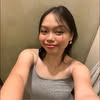

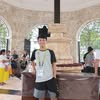

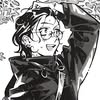

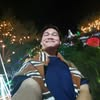

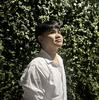

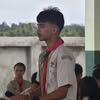

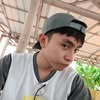

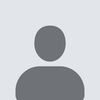

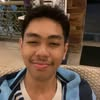

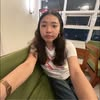

In [6]:
import sqlite3
import os
from datetime import date
from IPython.display import Image, display, HTML

def run_visual_dashboard_final():
    conn = sqlite3.connect("attendance_system.db")
    cursor = conn.cursor()

    # 1. SETUP TABLES (Exercise 2 & 3)
    cursor.execute("DROP TABLE IF EXISTS attendance")
    cursor.execute("DROP TABLE IF EXISTS user_profiles")
    
    cursor.execute("CREATE TABLE user_profiles (id INTEGER PRIMARY KEY, name TEXT, image_path TEXT)")
    cursor.execute("CREATE TABLE attendance (id INTEGER PRIMARY KEY AUTOINCREMENT, student_id INTEGER, date TEXT, status TEXT)")

    # 2. FULL DATASET (All 10 Students)
    student_data = [
        (4168, "Jumar L. Sinues",          r"C:\Users\VICTUS\Downloads\659653116_1703468970833446_272703917149371209_n.jpg"),
        (4754, "John Richmond M. Cleofe",  r"C:\Users\VICTUS\Downloads\524437625_1069335768623311_3503816022435004595_n.jpg"),
        (5870, "Kaye Celene G. Rivera",    r"C:\Users\VICTUS\Downloads\453178253_471506465671661_2781666950760530985_n.png"),
        (5552, "Gabriel T. Mañibo",        r"C:\Users\VICTUS\Downloads\451366031_1542655919651680_7837232138744884987_n.jpg"),
        (4496, "Ayisha Claire R. Angeles", r"C:\Users\VICTUS\Downloads\535024026_3340027876136844_2110705054149928168_n.jpg"),
        (3560, "John Michael C. Alvarez",  r"C:\Users\VICTUS\Downloads\602957600_1507159253905643_9111199985819837221_n.jpg"),
        (3570, "Trizz Ysabel V. Balingit", r"C:\Users\VICTUS\Downloads\658906761_26057547363916382_7619588506580847573_n.jpg"),
        (4172, "Jenny S. Guevarra",        r"C:\Users\VICTUS\Downloads\660299410_122157843122960428_3732621881511852220_n.jpg"),
        (11919, "Ralph Lorenz N. Villafuerte", r"C:\Users\VICTUS\Downloads\516363764_1934958507041369_5186842475668036312_n.jpg"),
        (1234, "Jhon Mark Osorio",         r"C:\Users\VICTUS\Downloads\481279884_614275044781323_9117859502307918080_n.jpg")
    ]

    today = date.today().strftime("%Y-%m-%d")

    # 3. INSERT & VALIDATE (Ex 3 requirements)
    print("--- SYSTEM NOTIFICATIONS ---")
    for s_id, name, path in student_data:
        ext = os.path.splitext(path)[1].lower()
        if ext in ['.jpg', '.jpeg', '.png']:
            cursor.execute("INSERT INTO user_profiles VALUES (?, ?, ?)", (s_id, name, path))
            cursor.execute("INSERT INTO attendance (student_id, date, status) VALUES (?, ?, ?)", 
                           (s_id, today, "Present"))
            print(f"Flash: Profile updated successfully for {name}!") # Ex 3 Output Requirement

    conn.commit()

    # 4. DASHBOARD VIEW (Actual Image Rendering)
    display(HTML("<h1 style='color: #2e7d32; font-family: sans-serif;'>STUDENT ATTENDANCE DASHBOARD</h1>"))
    
    cursor.execute("""
        SELECT up.name, up.image_path, att.status, att.date 
        FROM user_profiles up 
        JOIN attendance att ON up.id = att.student_id
        ORDER BY up.name ASC
    """)
    
    for name, full_path, status, att_date in cursor.fetchall():
        # Display the Profile Name and Status
        display(HTML(f"<h3>{name}</h3><p><b>Date:</b> {att_date} | <b>Status:</b> {status}</p>"))
        
        # RENDER THE IMAGE (Instead of printing code)
        if os.path.exists(full_path):
            display(Image(filename=full_path, width=150))
        else:
            display(HTML("<p style='color:red;'>[Image File Not Found]</p>"))
        
        display(HTML("<hr>"))

    conn.close()

run_visual_dashboard_final()